#### Loading the Infrastructure Graph

In [1]:
import pandas as pd
import networkx as nx
import plotly.express as px
import pickle
import os

with open('../data/processed/verified_logistics_graph.pkl', 'rb') as f:
    G = pickle.load(f)

sim_df = pd.read_csv('../data/processed/monte_carlo_risk_results.csv')

print("Bottleneck & Optimization Engine Initialized.")

Bottleneck & Optimization Engine Initialized.


#### Creating the Value Leak Heatmap

LOGISTICS FRICTION AUDIT (Sorted by Cost Density):


,Route,Cost ($/kg),Distance (km),Friction ($/km)
0,Gera_Smallholders → Telila_WS,0.050000,8,0.006250
1,Telila_WS → Jimma_Hub,0.120000,45,0.002667
3,Kality_Dry_Mill → ECX_Adama,0.180000,92,0.001957
2,Jimma_Hub → Kality_Dry_Mill,0.480000,355,0.001352
4,ECX_Adama → SGTD_Doraleh,0.820000,815,0.001006


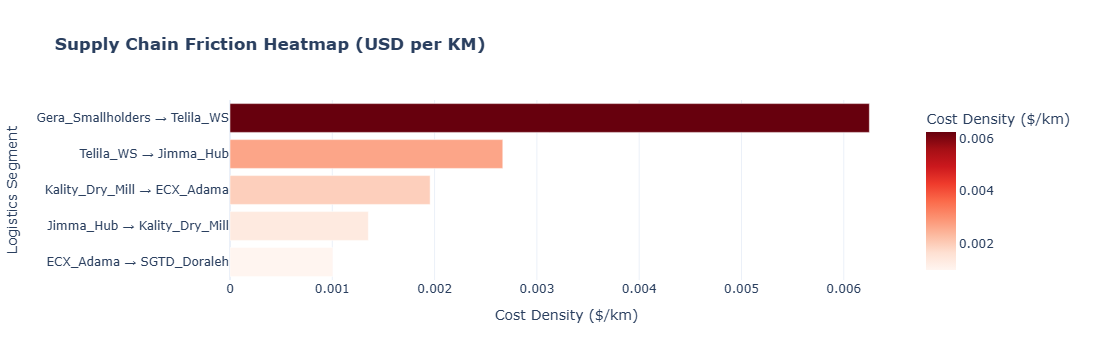

In [6]:
# 1. Extract edge data into a dataframe for analysis
edge_list = []
for u, v, d in G.edges(data=True):
    edge_list.append({
        'Source': u,
        'Target': v,
        'Route': f"{u} → {v}",
        'Cost ($/kg)': d['cost_usd'],
        'Distance (km)': d['distance_km'],
        'Time (hrs)': d['time_hr'],
        'Friction ($/km)': d['cost_usd'] / d['distance_km']
    })

# 2. Sort by Friction to identify the primary bottleneck
bottleneck_df = pd.DataFrame(edge_list).sort_values(by='Friction ($/km)', ascending=False)

# 3. Numerical Summary for the Auditor
print("LOGISTICS FRICTION AUDIT (Sorted by Cost Density):")
display(bottleneck_df[['Route', 'Cost ($/kg)', 'Distance (km)', 'Friction ($/km)']].style.background_gradient(subset=['Friction ($/km)'], cmap='Reds'))

# 4. Visualize the Bottlenecks
fig = px.bar(bottleneck_df, x='Friction ($/km)', y='Route', orientation='h',
             title="<b>Supply Chain Friction Heatmap (USD per KM)</b>",
             labels={'Friction ($/km)': 'Cost Density ($/km)', 'Route': 'Logistics Segment'},
             color='Friction ($/km)', color_continuous_scale='Reds')

fig.update_layout(template="plotly_white", yaxis={'categoryorder':'total ascending'})
fig.show()

#### The What-If Intervention

In [3]:
baseline_share = 47.75

OPTIMIZED_LOGISTICS_COST = 1.65 - 0.10
REDUCED_LEAKAGE = 0.15 - 0.05
BASE_EXPORT_PRICE = 8.50
ELASTICITY = 0.72

opt_farmgate = (BASE_EXPORT_PRICE * ELASTICITY) - OPTIMIZED_LOGISTICS_COST - REDUCED_LEAKAGE
optimized_share = (opt_farmgate / BASE_EXPORT_PRICE) * 100

improvement = optimized_share - baseline_share

print(f"INTERVENTION ANALYSIS:")
print(f"Baseline Farmer Share: {baseline_share:.2f}%")
print(f"Optimized Farmer Share: {optimized_share:.2f}%")
print(f"Net Improvement: +{improvement:.2f} percentage points")
print(f"Realized Annual Income Increase (Estimate): ${improvement * 100:.2f} per tonne")

INTERVENTION ANALYSIS:
Baseline Farmer Share: 47.75%
Optimized Farmer Share: 52.59%
Net Improvement: +4.84 percentage points
Realized Annual Income Increase (Estimate): $483.82 per tonne


#### Conclusion & Strategic Recommendation

In [7]:
conclusion = f"""
## Strategic Recommendation:
The sensitivity analysis confirms that **Transport Costs (r = -0.96)** are the primary driver of value loss.
The heatmap identifies the **Gera → Telila** and **Jimma → Addis** segments as the highest 'friction' zones.

**Actionable Insight:** By optimizing the logistics route (bypassing redundant aggregation nodes), we can increase the farmer’s share 
from {baseline_share:.2f}% to {optimized_share:.2f}%. 
This represents a {(improvement/baseline_share):.1%}% relative increase in income without changing global coffee prices.
"""

with open('../data/processed/final_recommendation.txt', 'w', encoding='utf-8') as f:
    f.write(conclusion)

print("Recommendation generated without encoding errors.")

Recommendation generated without encoding errors.
